In [1]:
import sys
sys.path.append('../src')

import joblib
import shap
import matplotlib.pyplot as plt
from preprocess import load_and_preprocess

X_train, X_test, y_train, y_test, feature_names = load_and_preprocess('../data/telco_churn.csv')
xgb = joblib.load('../models/xgb_churn.pkl')

print("Model and data loaded")

c:\Users\manoh\OneDrive\Desktop\PROJECTS\telecom-churn-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model and data loaded


In [2]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print("SHAP values computed, shape:", shap_values.shape)

SHAP values computed, shape: (1409, 21)


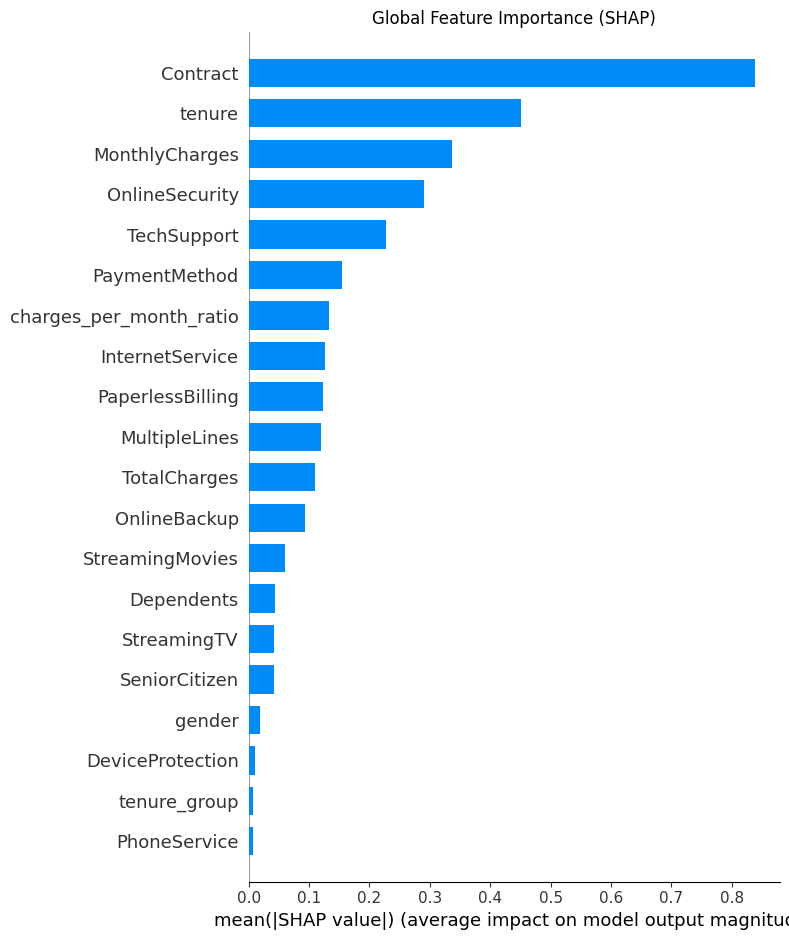

Saved to models/shap_global.png


In [3]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig('../models/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to models/shap_global.png")

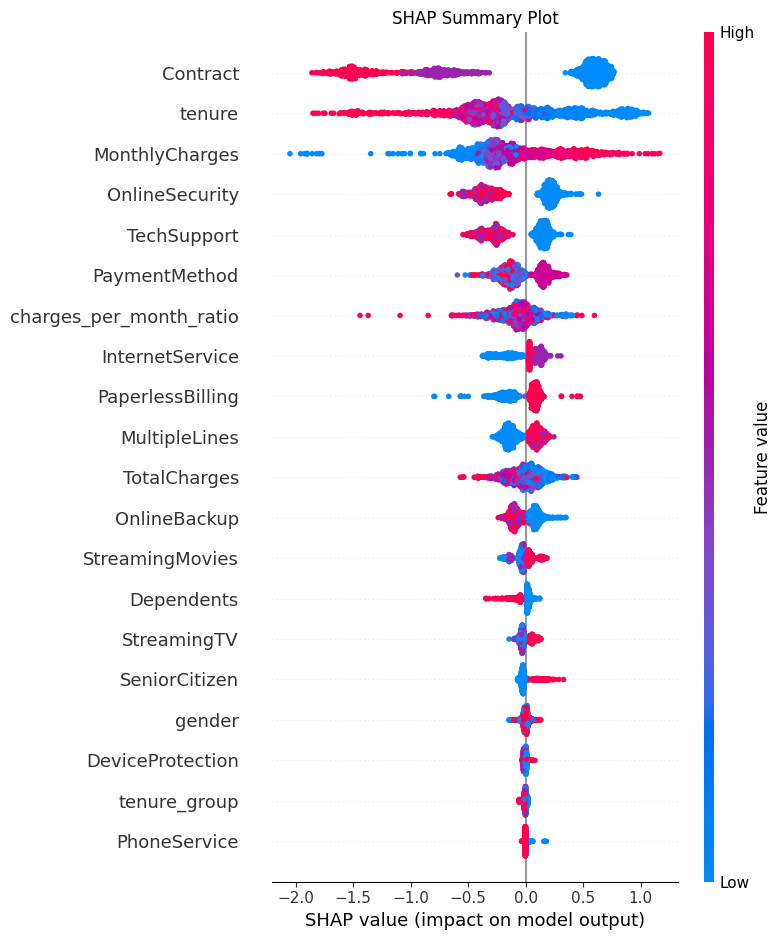

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

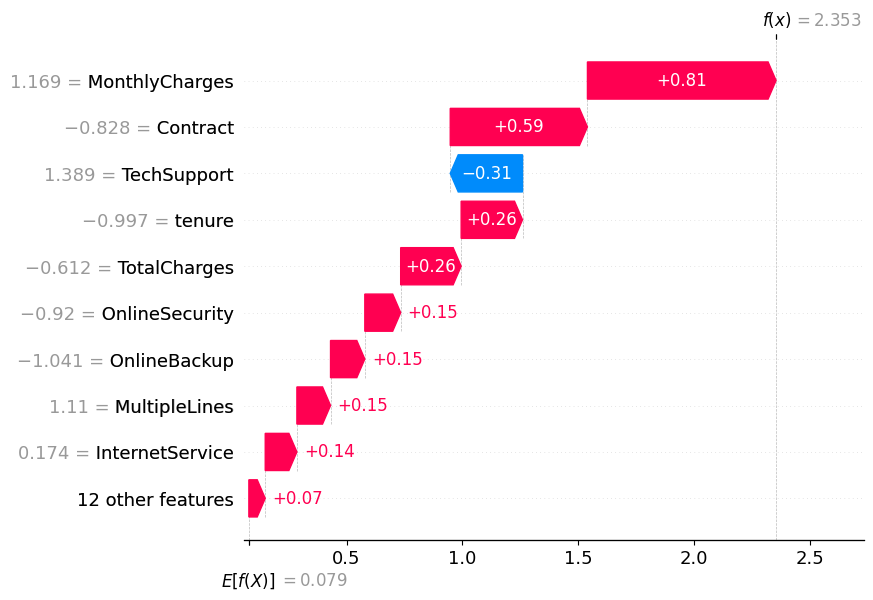

In [5]:
# Pick a customer the model predicts will churn
churn_indices = (xgb.predict(X_test) == 1)
first_churner = X_test[churn_indices].iloc[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[churn_indices][0],
        base_values=explainer.expected_value,
        data=first_churner.values,
        feature_names=feature_names
    )
)